# Small v/s Large Region more exposed (No Policies)

|Scenario                    |flags                                             |
|----------------------------|--------------------------------------------------|
|Baseline (No shocks)        |flag_shockexperiment = 0;                         |
|Capital Stock Shocks (CS)   | flag_shockexperiment = 1; flag_capshocks = 1;    |
|Productivity Shocks (LS+EF) | flag_shockexperiment = 1; flag_prodshock1 = 6;   |

In [93]:
from pathlib import Path
import sys

# Load reusable reader from scripts/read_batch_runs.py
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [94]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import plotly.graph_objects as go
import seaborn as sns


import plotly.graph_objects as go
from plotly.subplots import make_subplots

import scripts.read_batch_runs as _rbr
importlib.reload(_rbr)

from scripts.read_batch_runs import (
    load_simulation_results_matrix,
    check_regional_consistency,
)
from scripts.visualise_shocks import *
from scripts.compute_macros import *
from scripts.lineplots import *

## Define PATH

In [95]:
# define paths to experiment runs.
PATHS = {
    'small_more_exposed' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/experiment/SmallMoreExposed"),
    'large_more_exposed' : Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/experiment/LargeMoreExposed"),
    }
OUTPUT = Path("/Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/figures/experiment/")
OUTPUT.mkdir(parents=True, exist_ok=True)
# load simulation result matrices
sim_matrix = {}
for PATH in PATHS.keys():
    sim_matrix[PATH] = load_simulation_results_matrix(PATHS[PATH])

Found 3 scenario candidate folders under /Users/anmolsoni/Nextcloud/projects/Regionalised-SFC-DSK/experiment/SmallMoreExposed
Scenario 1: run_folders=50, max_run=50, macro_files_loaded=50, region_files_loaded=150, max_region=3, shock_files_loaded=0
  Scenario 1: saved to scenario_1.csv.gz
Column count mismatch: data_cols=80, yaml_cols=83.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=80, yaml_cols=83.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=80, yaml_cols=83.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=52, yaml_cols=55.
Column count mismatch: data_cols=80, yaml_cols=83.
Column count mismatch: data_cols=52, yaml_cols=

In [96]:
# Extract simulation results
scenario_results = {}
for sim in sim_matrix.keys():
    for scenario_num in sim_matrix[sim].scenario.unique():
        scenario_results[f"{sim}_{scenario_num}"] = sim_matrix[sim].loc[sim_matrix[sim].scenario == scenario_num]
        

## Compute Macros

In [97]:
def compare_scenarios(df_a, df_b, metric_a, metric_b=None, t_min=200, label_a="DSK", label_b="R-DSK", alpha=0.05, region="macro"):
    """Compare a metric between two scenario DataFrames using Welch's t-test.

    Observations are first averaged per Monte Carlo run (over t > t_min),
    so each run contributes exactly one independent data point to the test.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``, and ``metric``.
    metric_a : str
        Column name from df_a to compare (e.g. 'Unemployment', 'GDP_r_growth').
    metric_b : str
        Column name from  df_b to compare (e.g. 'Unemployment', 'GDP_r_growth').
    t_min : int, default 200
        Only include observations with t > t_min before averaging.
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    if metric_b is None:
        metric_b = metric_a
        
    # Filter to macro region if multiple regions present
    if "region" in df_a.columns and df_a["region"].nunique() > 1:
        df_a = df_a[df_a["region"] == region]
    if "region" in df_b.columns and df_b["region"].nunique() > 1:
        df_b = df_b[df_b["region"] == region]

    # Aggregate to run-level means (one independent observation per run)
    a = (
        df_a.loc[df_a["t"] > t_min, ["run", metric_a]]
        .groupby("run")[metric_a].mean()
        .dropna()
    )
    b = (
        df_b.loc[df_b["t"] > t_min, ["run", metric_b]]
        .groupby("run")[metric_b].mean()
        .dropna()
    )

    print(f"Metric : {metric_a} ({label_a}) and {metric_b} ({label_b})  (t > {t_min},  aggregated to run-level means)")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    # Welch's t-test on run-level means
    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal means across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")

    # ── Print table ─────────────────────────────────────────────────────────
    def _sig_star(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    ratio = b.mean() / a.mean()
    col_width = 22
    metric_display = metric_a if metric_a == metric_b else f"{metric_a}/{metric_b}"
    col_label = f"{label_b} / {label_a}"
    header_parts = [f"{'Metric':>25s}", f"{col_label:^{col_width}s}"]
    sep = "  ".join(["-" * 25, "-" * col_width])
    star = _sig_star(p_value)
    cell = f"{ratio:.4f} (t={t_stat:+.2f}){star}"

    print()
    print("  ".join(header_parts))
    print(sep)
    print("  ".join([f"{metric_display:>25s}", f"{cell:^{col_width}s}"]))
    print(sep)
    print(f"\nRatio = {label_b} / {label_a}  (run-level means, t > {t_min})")
    print(f"Significance: * p<0.05, ** p<0.01, *** p<0.001")
    print()


def compare_crisis_likelihood(df_a, df_b, t_min=200, threshold=-5.0,
                               label_a="DSK", label_b="HRHS", alpha=0.05):
    """Compare per-run crisis likelihood between two scenario DataFrames.

    For each run, crisis likelihood = proportion of quarters (t > t_min)
    where GDP_r_growth < threshold. The resulting per-run likelihoods are
    then compared with Welch's t-test, giving one independent observation
    per Monte Carlo run.

    Parameters
    ----------
    df_a, df_b : pandas.DataFrame
        Scenario DataFrames containing columns ``t``, ``run``,
        and ``GDP_r_growth``.
    t_min : int, default 200
        Only include observations with t > t_min.
    threshold : float, default -5.0
        Crisis threshold in percent (Lamperti et al. 2018: -5.0).
    label_a, label_b : str
        Display labels for each scenario in printed output.
    alpha : float, default 0.05
        Significance level for the test.
    """
    def _run_level_likelihood(df):
        # Filter to macro region if multiple regions present
        if "region" in df.columns and df["region"].nunique() > 1:
            df = df[df["region"] == "macro"]

        work = df.loc[df["t"] > t_min, ["run", "GDP_r_growth"]].copy()
        valid = work["GDP_r_growth"].notna()

        # Binary crisis flag per row
        work["_crisis"] = np.where(valid, (work["GDP_r_growth"] < threshold).astype(int), np.nan)

        # Per-run likelihood = crisis quarters / valid quarters
        obs   = work[valid].groupby("run")["_crisis"].count()
        crises = work[valid].groupby("run")["_crisis"].sum()
        return (crises / obs.replace(0, np.nan)).astype(float).dropna()

    a = _run_level_likelihood(df_a)
    b = _run_level_likelihood(df_b)

    print(f"Crisis likelihood  (GDP_r_growth < {threshold}%,  t > {t_min})")
    print(f"  {label_a:10s}  mean={a.mean():.4f}  std={a.std():.4f}  n_runs={len(a)}")
    print(f"  {label_b:10s}  mean={b.mean():.4f}  std={b.std():.4f}  n_runs={len(b)}")

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=True)
    print(f"\n  Welch's t-test  (H0: equal crisis likelihood across runs)")
    print(f"    t-statistic : {t_stat:.4f}")
    print(f"    p-value     : {p_value:.4e}")
    print(f"    Significant : {'Yes' if p_value < alpha else 'No'} (α = {alpha})")
    print()


In [98]:
for scenario in scenario_results.keys():
    #  Compute unemployment
    scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
    # Compute GDP volatility
    scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])
    #  Compute Output Growth Rate
    scenario_results[scenario]['GDP_r_growth'] = compute_gdp_r_growth(scenario_results[scenario])

/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_54482/1391837744.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['Unemployment'] = (1 - scenario_results[scenario].EmploymentRate) * 100
/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_54482/1391837744.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_volatility'] = compute_GDP_r_volatility(scenario_results[scenario])


In [99]:
for scenario in scenario_results.keys():
    #  Compute Real GDP (log-n)
    scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


/var/folders/1v/430f_9l153b4xn65sf8n__xm0000gn/T/ipykernel_54482/4169674518.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scenario_results[scenario]['GDP_r_ln'] = np.log(scenario_results[scenario]['GDP_r'])


In [100]:
scenario_results.keys()

dict_keys(['small_more_exposed_1', 'small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_1', 'large_more_exposed_2', 'large_more_exposed_3'])

In [101]:
compare_scenarios(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], metric_a="Unemployment",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], metric_a="GDP_r_volatility",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], metric_a="GDP_r_growth",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], metric_a="UnemploymentBenefit", metric_b="RegGov_SP",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], metric_a="Deficit", metric_b="Deficit",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["small_more_exposed_1"], scenario_results["large_more_exposed_1"], t_min=200, threshold=-5.0, label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

Metric : Unemployment (SmallMoreExposed) and Unemployment (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=4.2363  std=0.2880  n_runs=50
  LargeMoreExposed  mean=4.2363  std=0.2880  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : 0.0000
    p-value     : 1.0000e+00
    Significant : No (α = 0.05)

                   Metric  LargeMoreExposed / SmallMoreExposed
-------------------------  ----------------------
             Unemployment     1.0000 (t=+0.00)   
-------------------------  ----------------------

Ratio = LargeMoreExposed / SmallMoreExposed  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (SmallMoreExposed) and GDP_r_volatility (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=10.1242  std=0.7380  n_runs=50
  LargeMoreExposed  mean=10.1242  std=0.7380  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-stati

In [102]:
compare_scenarios(scenario_results["small_more_exposed_2"], scenario_results["large_more_exposed_2"], metric_a="Unemployment",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_2"], scenario_results["large_more_exposed_2"], metric_a="GDP_r_volatility",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_2"], scenario_results["large_more_exposed_2"], metric_a="GDP_r_growth",label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_2"], scenario_results["large_more_exposed_2"], metric_a="Deficit", metric_b="Deficit", label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["small_more_exposed_2"], scenario_results["large_more_exposed_2"], t_min=200, threshold=-5.0,
                               label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

Metric : Unemployment (SmallMoreExposed) and Unemployment (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=5.6828  std=0.2833  n_runs=50
  LargeMoreExposed  mean=6.0916  std=0.2107  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -8.1878
    p-value     : 1.0065e-12
    Significant : Yes (α = 0.05)

                   Metric  LargeMoreExposed / SmallMoreExposed
-------------------------  ----------------------
             Unemployment   1.0720 (t=-8.19)***  
-------------------------  ----------------------

Ratio = LargeMoreExposed / SmallMoreExposed  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (SmallMoreExposed) and GDP_r_volatility (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=8.7385  std=0.7167  n_runs=50
  LargeMoreExposed  mean=9.1767  std=0.7456  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-stati

In [103]:
compare_scenarios(scenario_results["small_more_exposed_3"], scenario_results["large_more_exposed_3"], metric_a="Unemployment", label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_3"], scenario_results["large_more_exposed_3"], metric_a="GDP_r_volatility", label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_3"], scenario_results["large_more_exposed_3"], metric_a="GDP_r_growth", label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)
compare_scenarios(scenario_results["small_more_exposed_3"], scenario_results["large_more_exposed_3"], metric_a="Deficit", metric_b="Deficit", label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

     #  Compute Crisis Likelihood
compare_crisis_likelihood(scenario_results["small_more_exposed_3"], scenario_results["large_more_exposed_3"], t_min=200, threshold=-5.0,
                               label_a="SmallMoreExposed", label_b="LargeMoreExposed", alpha=0.05)

Metric : Unemployment (SmallMoreExposed) and Unemployment (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=5.6775  std=0.2543  n_runs=50
  LargeMoreExposed  mean=5.7621  std=0.2983  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statistic : -1.5261
    p-value     : 1.3021e-01
    Significant : No (α = 0.05)

                   Metric  LargeMoreExposed / SmallMoreExposed
-------------------------  ----------------------
             Unemployment     1.0149 (t=-1.53)   
-------------------------  ----------------------

Ratio = LargeMoreExposed / SmallMoreExposed  (run-level means, t > 200)
Significance: * p<0.05, ** p<0.01, *** p<0.001

Metric : GDP_r_volatility (SmallMoreExposed) and GDP_r_volatility (LargeMoreExposed)  (t > 200,  aggregated to run-level means)
  SmallMoreExposed  mean=8.6967  std=0.6667  n_runs=50
  LargeMoreExposed  mean=8.6958  std=0.6862  n_runs=50

  Welch's t-test  (H0: equal means across runs)
    t-statis

## Compare Macro-level variables

### Real GDP

In [104]:
scenario_results.keys()

dict_keys(['small_more_exposed_1', 'small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_1', 'large_more_exposed_2', 'large_more_exposed_3'])

In [105]:
SCENARIOS = {
    "Small More Exposed: No Shock": {"df": scenario_results["small_more_exposed_1"], "color": "#009933", 'dash': 'solid'},
    "Small More Exposed: CS": {"df": scenario_results["small_more_exposed_2"], "color": "#ff3300",'dash': 'solid'},
    "Small More Exposed: LP + EF": {"df": scenario_results["small_more_exposed_3"], "color": "#0052cc",'dash': 'solid'},
    "Large More Exposed: No Shock": {"df": scenario_results["large_more_exposed_1"], "color": "#00ff55", 'dash': 'dot'},
    "Large More Exposed: CS": {"df": scenario_results["large_more_exposed_2"], "color": "#ff9980", 'dash': 'dot'},
    "Large More Exposed: LP + EF": {"df": scenario_results["large_more_exposed_3"], "color": "#66a3ff", 'dash': 'dot'}
}

PDF_PAGES = [
    None,                                       # page 1: all scenarios
    ["Small More Exposed: No Shock"],                          # page 2: dsk_sfc_1
    ["Small More Exposed: No Shock", "Large More Exposed: No Shock"],     # page 3: dsk_sfc_1 + hrhs_1
    ["Small More Exposed: CS"],                                # page 4: dsk_sfc_2
    ["Small More Exposed: CS", "Large More Exposed: CS"],                 # page 5: dsk_sfc_2 + hrhs_2
    ["Small More Exposed: LP + EF"],                           # page 6: dsk_sfc_3
    ["Small More Exposed: LP + EF", "Large More Exposed: LP + EF"],       # page 7: dsk_sfc_3 + hrhs_3
]

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_ln",
    metric_label='ln',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_ln_line.pdf",
    # ymin=12.8, ymax=14
)

fig1

# fig1.write_image("../figures/verification/GDP_r_ln.pdf", width=750, height=500, scale=2)
# fig1.write_html("../figures/verification/GDP_r_ln.html", include_plotlyjs="cdn")

In [106]:

SCENARIOS = {
    "Small More Exposed: No Shock": {"df": scenario_results["small_more_exposed_1"], "color": "#009933", 'dash': 'solid'},
    "Small More Exposed: CS": {"df": scenario_results["small_more_exposed_2"], "color": "#ff3300",'dash': 'solid'},
    "Small More Exposed: LP + EF": {"df": scenario_results["small_more_exposed_3"], "color": "#0052cc",'dash': 'solid'},
    "Large More Exposed: No Shock": {"df": scenario_results["large_more_exposed_1"], "color": "#00ff55", 'dash': 'dot'},
    "Large More Exposed: CS": {"df": scenario_results["large_more_exposed_2"], "color": "#ff9980", 'dash': 'dot'},
    "Large More Exposed: LP + EF": {"df": scenario_results["large_more_exposed_3"], "color": "#66a3ff", 'dash': 'dot'}
}
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_h",
    metric_label='Networth of Households',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of Households',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=25000000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_h_line.pdf",
)

fig1

In [107]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_1",
    metric_label='Networth of K-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of K-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    ymin=0, ymax=1500000,
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_1_line.pdf",
)


fig1

In [108]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_2",
    metric_label='Networth of C-Firms',
    snap_ts=np.arange(0, 620, 20),
    title='Networth of C-Firms',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_2_line.pdf",
    # ymin=12.8, ymax=14
)

fig1

In [109]:
fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="NW_gov_over_GDPn",
    metric_label='Networth of Central Government / GDP',
    snap_ts=np.arange(200, 620, 20),
    title='',
    line_type='lines',
    ncol_legend=3,
    CI_type='error_bar',
    # ymin=-0.25, ymax=-0.14,
        pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "NW_gov_over_GDP_line.pdf",
)

fig1

Resorting to unclean kill browser.


In [110]:
def plot_boxplots(
    metric,
    scenario_names,
    labels=None,
    title="Standard deviation of filtered real GDP",
    colors=None,
    y_label="Std. Dev. of GDP_r",
    figsize=(6, 5.5),
    dpi=140,
    save_path=None,
):
    """Plot given metric as a notched Matplotlib box plot.

    Parameters
    ----------
    metric : dict
        Mapping scenario name -> pandas Series/array of metric values.
    scenario_names : list[str]
        Scenarios to plot in this order.
    labels : list[str] | None
        Display labels for x-axis. If None, scenario_names are used.
    title : str
        Figure title.
    colors : list[str] | dict[str, str] | None
        Box outline/median colors. If dict, keyed by scenario name.
    y_label : str
        Y-axis label.
    figsize : tuple[float, float]
        Figure size in inches.
    dpi : int
        Figure resolution.
    save_path : str | None
        Optional path to save the figure.
    """
    if labels is None:
        labels = scenario_names

    if len(labels) != len(scenario_names):
        raise ValueError("labels length must match scenario_names length")

    missing = [name for name in scenario_names if name not in metric]
    if missing:
        raise KeyError(f"Missing scenarios in gdp_r_std: {missing}")

    if colors is None:
        palette = ["#0B9E77", "#E41A1C", "#56B4E9"]
        color_list = [palette[i % len(palette)] for i in range(len(scenario_names))]
    elif isinstance(colors, dict):
        color_list = [colors[name] for name in scenario_names]
    else:
        if len(colors) != len(scenario_names):
            raise ValueError("colors length must match scenario_names length")
        color_list = list(colors)

    data = []
    for name in scenario_names:
        values = metric[name]
        if hasattr(values, "dropna"):
            values = values.dropna()
        data.append(np.asarray(values, dtype=float))

    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    bp = ax.boxplot(
        data,
        tick_labels=labels,
        notch=True,
        patch_artist=True,
        widths=0.75,
        showfliers=True,
        whis=1.5,
    )

    for i, box in enumerate(bp["boxes"]):
        box.set(facecolor="none", edgecolor=color_list[i], linewidth=1.5)

    for i, whisker in enumerate(bp["whiskers"]):
        whisker.set(color=color_list[i // 2], linewidth=1.3)

    for i, cap in enumerate(bp["caps"]):
        cap.set(color=color_list[i // 2], linewidth=1.3)

    for i, median in enumerate(bp["medians"]):
        median.set(color=color_list[i], linewidth=2.4)

    for i, flier in enumerate(bp["fliers"]):
        flier.set(
            marker="o",
            markersize=5,
            markerfacecolor=color_list[i],
            markeredgecolor=color_list[i],
            alpha=1.0,
        )

    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_facecolor("#ffffff")
    ax.grid(True, axis="both", alpha=0.36, color='gray', linestyle='--', linewidth=0.5, which='both')

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()

#### Avg. Annualized Real GDP Growth

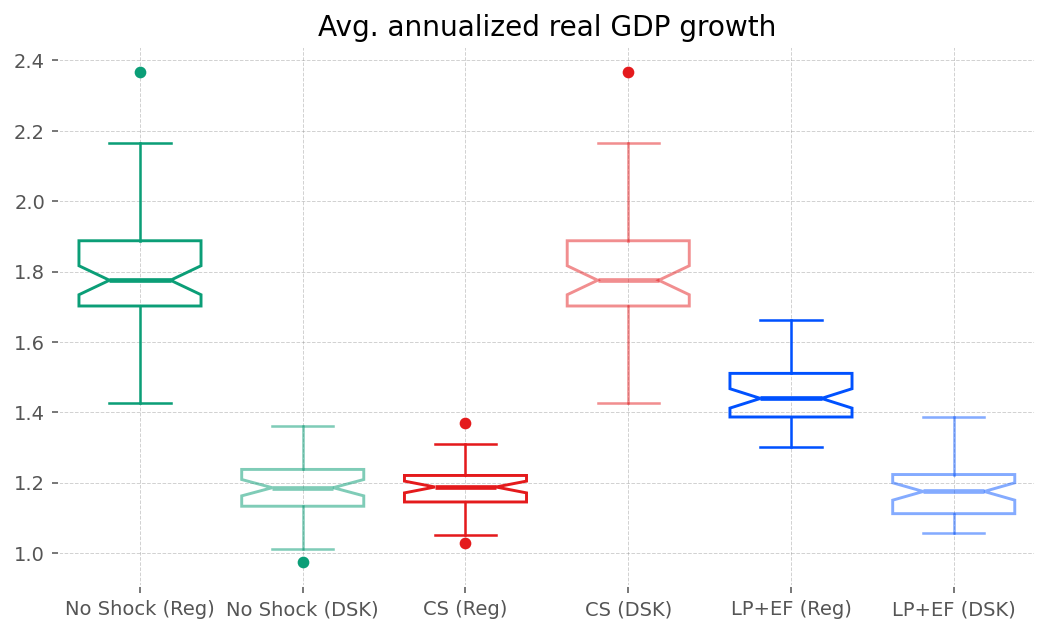

In [111]:
GDP_r_annualized_growth = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    GDP_r_annualized_growth[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()



plot_boxplots(
    metric=GDP_r_annualized_growth,
    scenario_names=['small_more_exposed_1', 'small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_1', 'large_more_exposed_2', 'large_more_exposed_3'],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(9, 5),
    title="Avg. annualized real GDP growth",
    y_label='',
    save_path=OUTPUT / "GDP_r_annualized_growth.pdf"
)

### GDP Growth

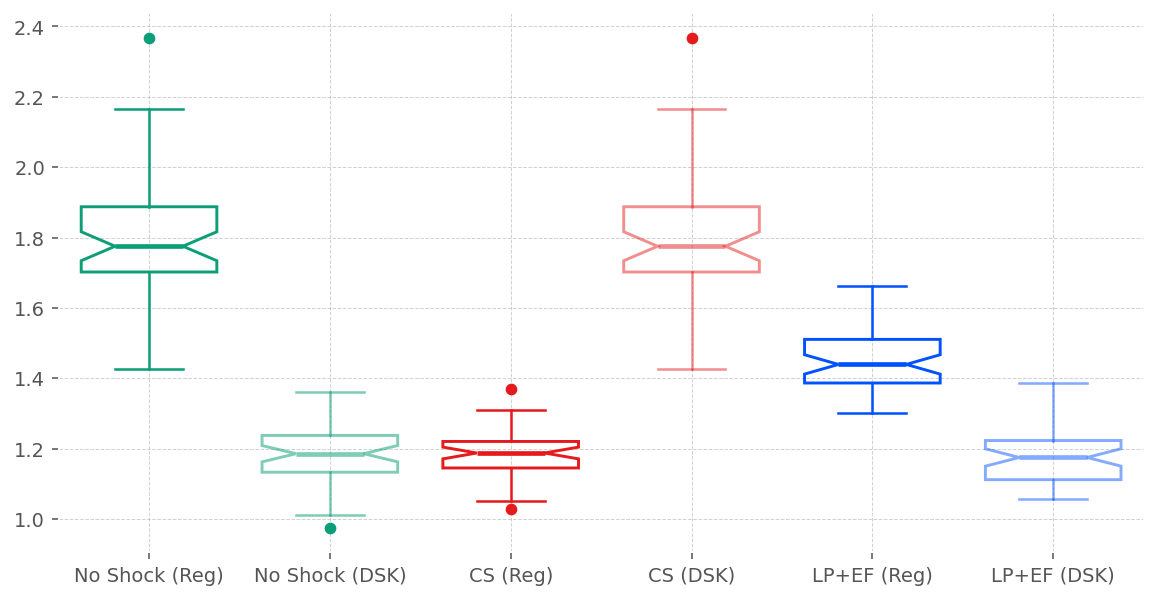

In [112]:
metric = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    metric[scenario] = temp_df.groupby(['run'])['GDP_r_growth'].mean()
        

plot_boxplots(
    metric=metric,
    scenario_names=['small_more_exposed_1', 'small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_1', 'large_more_exposed_2', 'large_more_exposed_3'],
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="",
    y_label='',
    save_path=OUTPUT/"GDP_r_growth.pdf",
)

In [113]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="GDP_r_growth",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='Real GDP Growth',
    line_type='lines',
    ncol_legend=3,
    ymin=-15,
    ymax=20,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "GDP_r_growth_line.pdf",
)
fig1


### Bad debt as % of nominal GDP

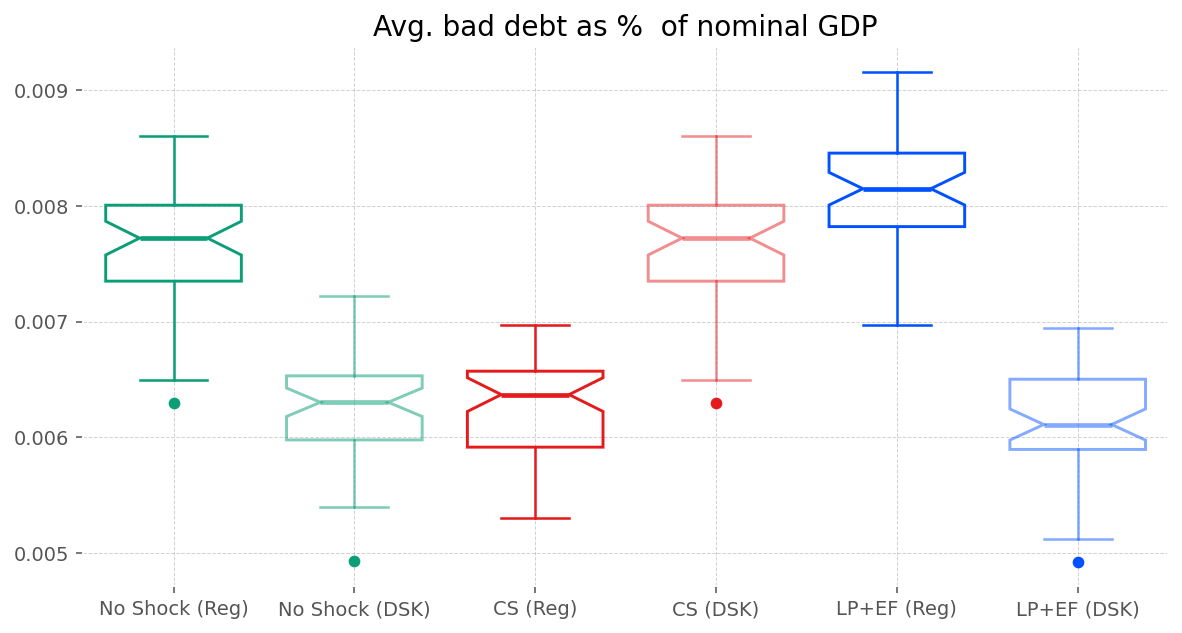

In [114]:
bad_debt_b_over_GDPn = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    bad_debt_b_over_GDPn[scenario] = temp_df.groupby(['run'])['baddebt_b_over_GDP'].mean()
        

plot_boxplots(
    metric=bad_debt_b_over_GDPn,
    scenario_names=scenario_results.keys(),
    labels=["No Shock (Reg)", "No Shock (DSK)", "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"],
    figsize=(10, 5),
    title="Avg. bad debt as %  of nominal GDP",
    y_label='',
    save_path=OUTPUT/"baddebt_b_over_GDP.pdf",
)

In [115]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric="baddebt_b_over_GDP",
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title='baddebt_b_over_GDP',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=0.015,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "baddebt_line.pdf",
)
fig1

### Number of C-Firms failure

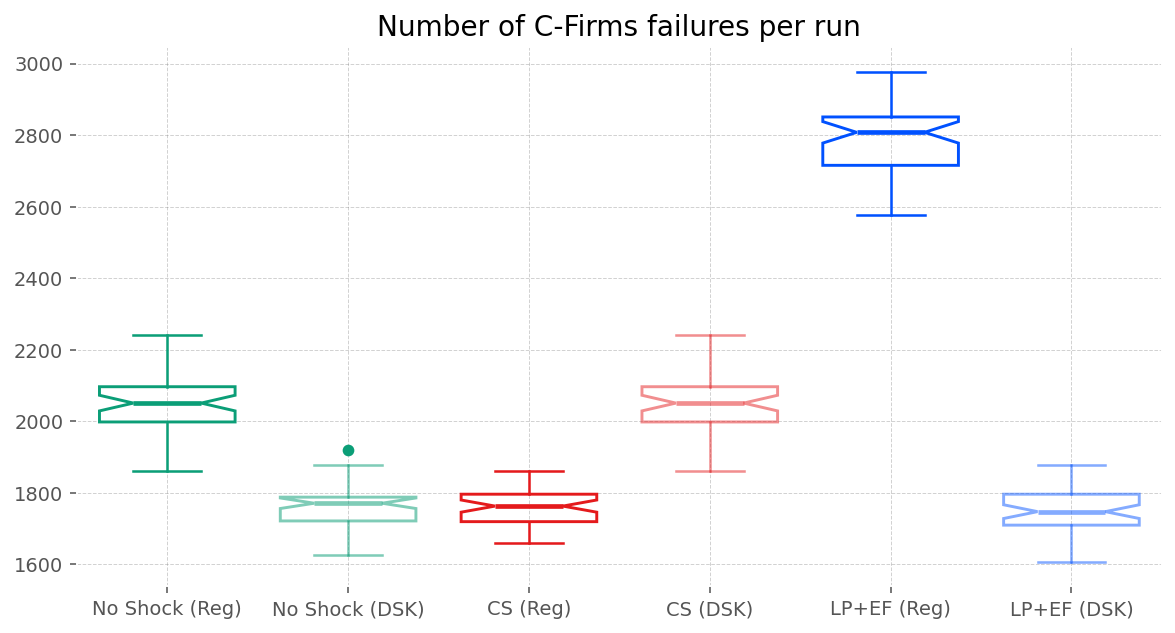

In [116]:
Exiting_CFirms = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Exiting_CFirms[scenario] = temp_df.groupby(['run'])['Exiting_C-Firms'].sum()
        

plot_boxplots(
    metric=Exiting_CFirms,
    scenario_names=scenario_results.keys(),
    labels=["No Shock (Reg)", "No Shock (DSK)", 
            "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Number of C-Firms failures per run",
    y_label='',
    save_path=OUTPUT / "Exiting_C-Firms.pdf",
)

In [117]:

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric='Exiting_C-Firms',
    metric_label='Avg. Cfirms exiting per run',
    snap_ts=np.arange(200, 620, 20),
    title='Exiting_C-Firms',
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=12,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / "Exiting_C-Firms_line.pdf",
)
fig1

### Unemployment

In [118]:
metric = "Unemployment"

fig1 = build_macro_snapshot_metric_figure(
    scenarios=SCENARIOS,
    metric=metric,
    metric_label='',
    snap_ts=np.arange(200, 620, 20),
    title=metric,
    line_type='lines',
    ncol_legend=3,
    ymin=0,
    ymax=10,
    CI_type='error_bar',
    pdf_pages=PDF_PAGES,
    pdf_path=OUTPUT / f"{metric}.pdf",
)
fig1


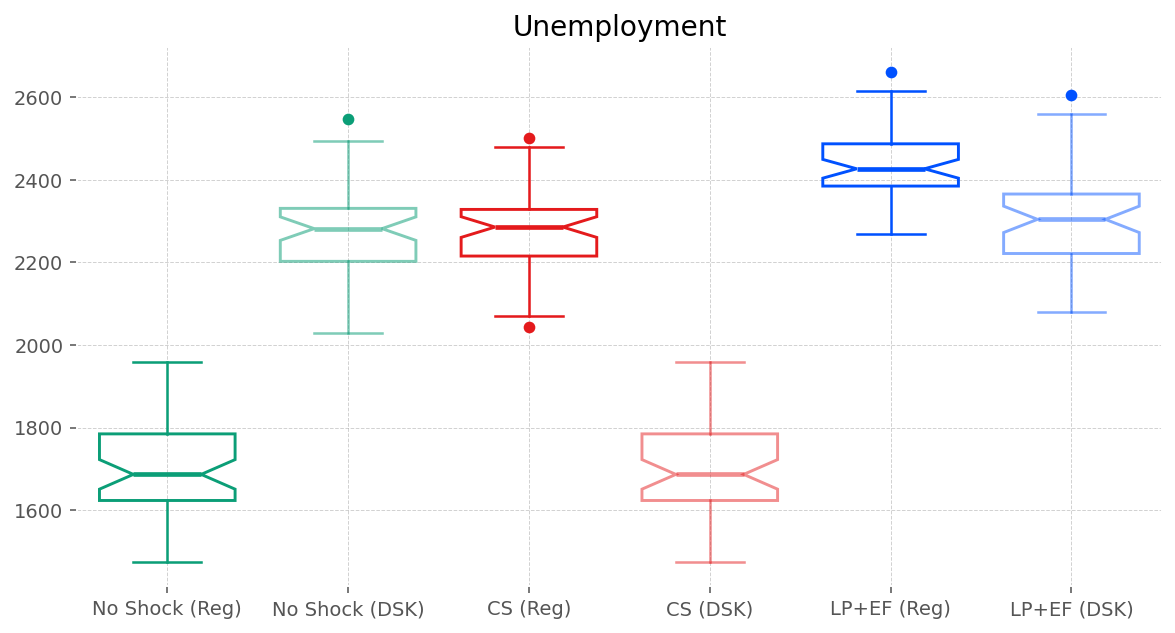

In [119]:
Unemployment = {}
for scenario in scenario_results.keys():
    temp_df = scenario_results[scenario][scenario_results[scenario]['region']=='macro'].copy()
    temp_df = temp_df[temp_df['t']>200].copy()
    Unemployment[scenario] = temp_df.groupby(['run'])['Unemployment'].sum()
        

plot_boxplots(
    metric=Unemployment,
    scenario_names=scenario_results.keys(),
    labels=["No Shock (Reg)", "No Shock (DSK)", 
            "CS (Reg)","CS (DSK)" , "LP+EF (Reg)", "LP+EF (DSK)"],
    colors=["#0B9E77","#0B9E7786", 
            "#E41A1C","#E41A1D7E", "#0051FF","#0051FF7B"
            ],
    figsize=(10, 5),
    title="Unemployment",
    y_label='',
    save_path=OUTPUT / "Unemployment_box.pdf",
)

### Sectoral net worth as % of nominal GDP

In [120]:
BG_COLOR = "white"  # use "rgba(0,0,0,0)" for transparent
GRID_COLOR = "rgba(128, 128, 128, 0.5)"

mean_sectoral_net_worth = {}
sectoral_net_worth = {}
sector_order = ["K-Firms", "C-Firms", "Households", "Banks", "Energy", "Govt."]

for scenario in ["small_more_exposed_1", "large_more_exposed_1", ]:
    temp_df = scenario_results[scenario][scenario_results[scenario]["region"] == "macro"].copy()
    temp_df = temp_df[temp_df["t"] > 200].copy()
    for column in ["NW_1", "NW_2", "NW_h"]:
        temp_df[f"{column}_over_GDPn"] = temp_df[column] / (temp_df["GDP_n"] * 4)
    columns_dict = dict(
        zip(
            [
                "NW_1_over_GDPn",
                "NW_2_over_GDPn",
                "NW_h_over_GDPn",
                "NW_b_over_GDPn",
                "NW_e_over_GDPn",
                "NW_gov_over_GDPn",
            ],
            sector_order,
        )
    )
    temp_df.rename(columns=columns_dict, inplace=True)
    sectoral_net_worth[scenario] = temp_df

# ["dsk_sfc_2", "dsk_sfc_3", "hrhs_2", "hrhs_3"]
# for scenario in ["hrhs_3", ]:
#     net_worth = {}
#     for sector in sector_order:
#         if scenario.startswith("dsk"):
#             baseline = "dsk_sfc_1"
#         elif scenario.startswith("hrhs"):
#             baseline = "hrhs_1"

#         scenario_pairs = sectoral_net_worth[scenario][["t", "run", sector]].rename(
#             columns={sector: "scenario_val"}
#         )
#         baseline_pairs = sectoral_net_worth[baseline][["t", "run", sector]].rename(
#             columns={sector: "baseline_val"}
#         )

#         paired = scenario_pairs.merge(baseline_pairs, on=["t", "run"], how="inner")
#         paired["diff"] = (paired["scenario_val"] - paired["baseline_val"]) * 100

#         diff_by_t = paired.groupby("t")["diff"]
#         mean_diff = diff_by_t.mean()
#         n = diff_by_t.count().replace(0, np.nan)
#         std_diff = diff_by_t.std(ddof=1)
#         se_diff = std_diff / np.sqrt(n)
#         ci95 = 1.96 * se_diff

#         net_worth[sector] = {
#             "mean": mean_diff,
#             "ci95": ci95,
#         }
#     mean_sectoral_net_worth[scenario] = net_worth


color_dict = dict(
    zip(
        sector_order,
        [
            dict(color="rgb(219, 161, 55)"),
            dict(color="rgb(110, 177, 228)"),
            dict(color="rgb(19, 155, 116)"),
            dict(color="rgb(238, 227, 97)"),
            dict(color="rgb(69, 155, 116)"),
            dict(color="rgb(48, 111, 173)"),
        ],
    )
)

for scenario in mean_sectoral_net_worth.keys():
    fig = go.Figure()
    ci_trace_indices = []

    # 1) Add all sector mean lines first (legend row 1)
    for sector in sector_order:
        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=mean_series.values,
                mode="lines",
                name=sector,
                line=color_dict[sector],
                legendgroup=f"line_{sector}",
                showlegend=True,
            )
        )

    # 2) Add all confidence bands second (legend row 2)
    for sector in sector_order:
        line_color = color_dict[sector]["color"]
        fill_color = line_color.replace("rgb(", "rgba(").replace(")", ", 0.25)")

        mean_series = mean_sectoral_net_worth[scenario][sector]["mean"]
        ci_series = mean_sectoral_net_worth[scenario][sector]["ci95"].reindex(mean_series.index).fillna(0)
        upper = mean_series + ci_series
        lower = mean_series - ci_series

        ci_group = f"ci_{sector}"

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=upper.values,
                mode="lines",
                line=dict(width=0),
                legendgroup=ci_group,
                showlegend=False,
                hoverinfo="skip",
            )
        )

        ci_trace_indices.append(len(fig.data))
        fig.add_trace(
            go.Scatter(
                x=mean_series.index.to_list(),
                y=lower.values,
                mode="lines",
                line=dict(width=0),
                fill="tonexty",
                fillcolor=fill_color,
                legendgroup=ci_group,
                name="(95% CI)",
                showlegend=True,
                hoverinfo="skip",
            )
        )
        # fig.update_yaxes(range=[-4, 4])

    fig.update_layout(
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        width=1200,
        height=500,
        xaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        yaxis=dict(
            showgrid=True,
            gridcolor=GRID_COLOR,
            zeroline=True,
            zerolinecolor=GRID_COLOR,
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.20,
            xanchor="center",
            x=0.5,
            traceorder="normal",
            groupclick="togglegroup",
            entrywidthmode="fraction",
            entrywidth=0.16,
            tracegroupgap=0,
        ),
        margin=dict(b=150),
        )

    fig

In [121]:
fig.show()

In [122]:
scenario_results.keys()

dict_keys(['small_more_exposed_1', 'small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_1', 'large_more_exposed_2', 'large_more_exposed_3'])

### Emissions

In [123]:
Emiss_TOT = pd.DataFrame()
for scenario in ['small_more_exposed_2', 'small_more_exposed_3', 'large_more_exposed_2', 'large_more_exposed_3']:
    if scenario.startswith('small_more_exposed'):
        baseline = 'small_more_exposed_1'
    elif scenario.startswith('large_more_exposed'):
        baseline = 'large_more_exposed_1'
    Emiss_TOT[scenario] =  (scenario_results[scenario].groupby('t')['Emiss_TOT'].mean() - (scenario_results[baseline].groupby('t')['Emiss_TOT'].mean())) / scenario_results[baseline].groupby('t')['Emiss_TOT'].mean() * 100

In [124]:
def build_emissions_change_figure(
    scenario_results,
    scenarios,
    baseline,
    line_colors,
    band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
):
    fig = go.Figure()

    for scenario in scenarios:
        sc_df = scenario_results[scenario].loc[
            scenario_results[scenario]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]
        bl_df = scenario_results[baseline].loc[
            scenario_results[baseline]['region'] == 'macro', ['t', 'run', 'Emiss_TOT']
        ]

        paired = sc_df.merge(bl_df, on=['t', 'run'], suffixes=('_sc', '_bl'))
        paired['diff_pct'] = (
            (paired['Emiss_TOT_bl'] - paired['Emiss_TOT_sc'])
            / paired['Emiss_TOT_sc'].abs()
            * 100
        )
        paired = paired[paired['t'] > t_min]

        diff_by_t = paired.groupby('t')['diff_pct']
        mean_diff = diff_by_t.mean()
        n = diff_by_t.count().replace(0, np.nan)
        std_diff = diff_by_t.std(ddof=1)
        ci95 = 1.96 * std_diff / np.sqrt(n)

        x = mean_diff.index.to_numpy()
        upper = (mean_diff + ci95).to_numpy()
        lower = (mean_diff - ci95).to_numpy()

        if scenario.endswith('2'):
            name = 'CS'
        elif scenario.endswith('3'):
            name = 'LP+EF'
        fig.add_trace(go.Scatter(
            x=x,
            y=mean_diff.to_numpy(),
            mode='lines',
            name=name,
            line=dict(color=line_colors[scenario], width=2),
        ))

        fig.add_trace(go.Scatter(
            x=np.concatenate([x, x[::-1]]),
            y=np.concatenate([upper, lower[::-1]]),
            fill='toself',
            fillcolor=band_colors[scenario],
            line=dict(width=0),
            hoverinfo='skip',
            showlegend=False,
            name=f'{scenario} 95% CI',
        ))

    # fig.update_yaxes(range=[-10, 10], )

    fig.update_layout(
        width=800,
        height=500,
        title=title,
        xaxis_title='Timestep (t)',
        yaxis_title='Δ Emiss_TOT (%)',
        hovermode='x',
        plot_bgcolor=BG_COLOR,
        paper_bgcolor=BG_COLOR,
        xaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        yaxis=dict(showgrid=True, gridcolor=GRID_COLOR, zeroline=True, zerolinecolor=GRID_COLOR),
        template='simple_white',
        legend=dict(
            orientation='h',
            x=0.5,
            xanchor='center',
            y=-0.2,
            yanchor='top',
        ),
        margin=dict(b=90),
    )

    return fig



In [125]:
line_colors = {
    'small_more_exposed_2': 'rgb(220, 38, 38)',
    'small_more_exposed_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'small_more_exposed_2': 'rgba(220, 38, 38, 0.2)',
    'small_more_exposed_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['small_more_exposed_2', 'small_more_exposed_3'],
    baseline='small_more_exposed_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(OUTPUT / f"Emissions_small_more_exposed.pdf", scale=1)
fig.show()

In [126]:
line_colors = {
    'large_more_exposed_2': 'rgb(220, 38, 38)',
    'large_more_exposed_3': 'rgb(37, 99, 235)',
}
band_colors = {
    'large_more_exposed_2': 'rgba(220, 38, 38, 0.2)',
    'large_more_exposed_3': 'rgba(37, 99, 235, 0.2)',
}

fig = build_emissions_change_figure(
    scenario_results=scenario_results,
    scenarios=['large_more_exposed_2', 'large_more_exposed_3'],
    baseline='large_more_exposed_1',
    line_colors=line_colors,
    band_colors=band_colors,
    t_min=200,
    title='Emissions change vs baseline (%)',
)

fig.write_image(OUTPUT / f"Emissions_large_more_exposed.pdf", scale=1)
fig.show()

## Regional consistency

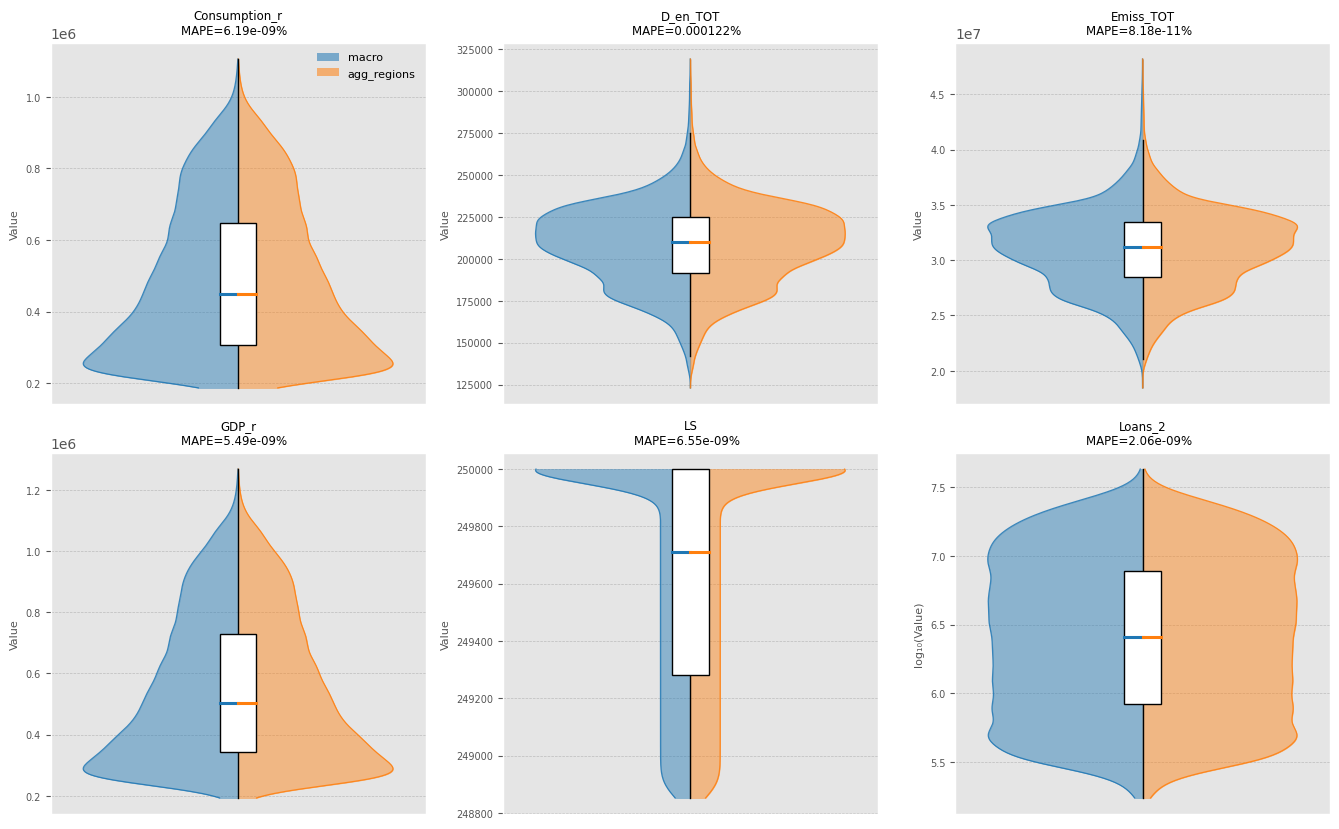

        variable  n_obs     mean_bias       mae      rmse  mean_abs_pct_err  \
0  Consumption_r  30000  1.410205e-08  0.000025  0.000029      6.193930e-09   
1       D_en_TOT  30000  1.930242e-03  0.250937  0.289532      1.222858e-04   
2      Emiss_TOT  30000  2.925616e-07  0.000025  0.000029      8.183281e-11   
3          GDP_r  30000  3.156218e-08  0.000025  0.000029      5.489587e-09   
4             LS  30000 -1.011100e-06  0.000016  0.000023      6.550947e-09   
5        Loans_2  30000  3.058412e-07  0.000025  0.000029      2.061180e-09   

   max_abs_pct_err  corr  welch_t_pvalue  cohens_d     ks_pvalue  close_ratio  \
0     2.587873e-08   1.0        1.000000  0.000488  1.000000e+00          1.0   
1     3.624536e-04   1.0        0.999992  0.006667  1.000000e+00          1.0   
2     2.401376e-10   1.0        1.000000  0.010145  1.000000e+00          1.0   
3     2.445257e-08   1.0        1.000000  0.001094  1.000000e+00          1.0   
4     2.002168e-08   1.0        1.000000 

In [127]:


check_regional_consistency(
    scenario_results['large_more_exposed_1'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'LS', 
    'Emiss_TOT',
    'Consumption_r',
    'Loans_2', 'D_en_TOT'],
    },
    output = OUTPUT / "regional_consistency_NoShock.pdf"
)

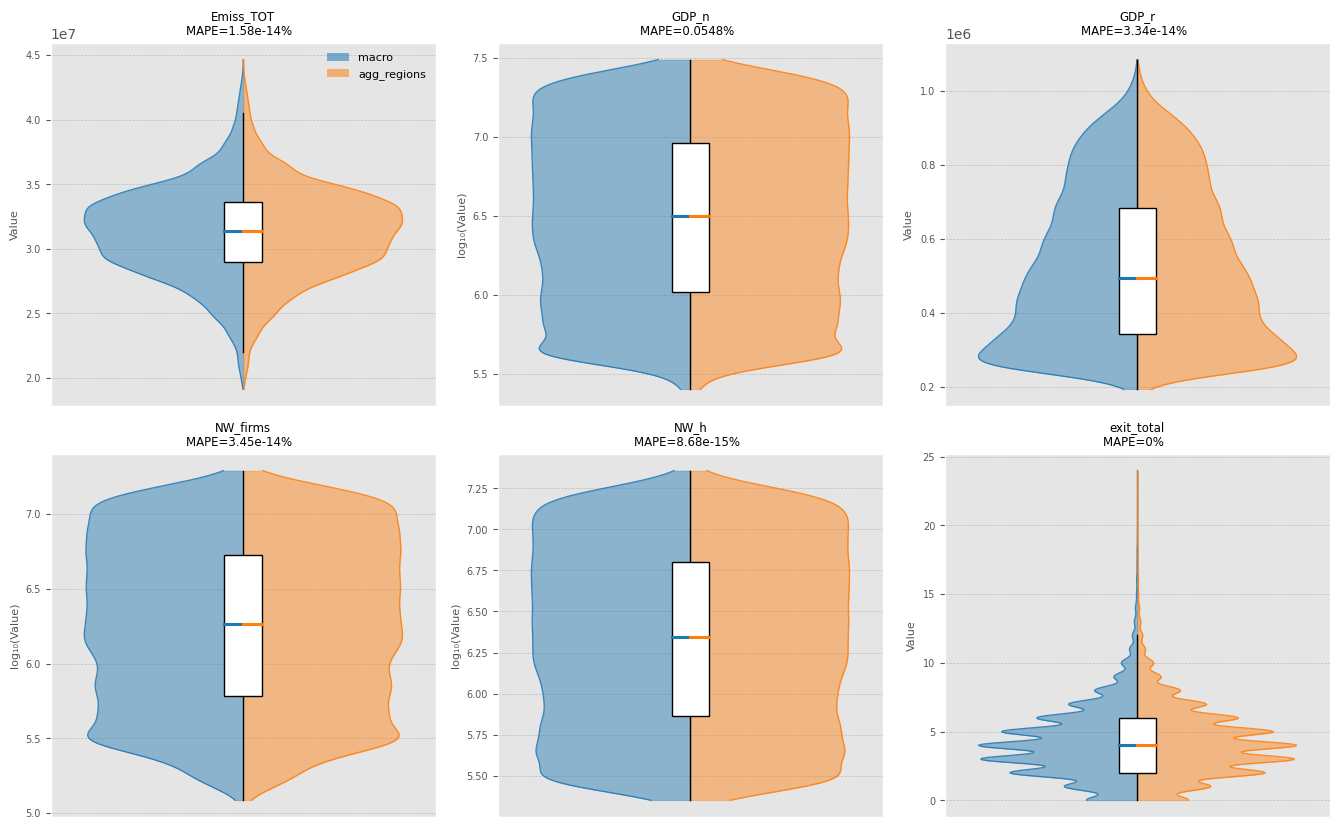

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000 -9.002785e-11  4.906828e-09  6.647008e-09   
1       GDP_n  30000 -3.342118e+03  3.342118e+03  5.805475e+03   
2       GDP_r  30000 -1.808318e-12  1.724557e-10  2.353497e-10   
3    NW_firms  30000  3.264092e-11  1.234528e-09  2.335187e-09   
4        NW_h  30000  5.116841e-11  3.305419e-10  7.642768e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.576951e-14     2.135398e-13   1.0        1.000000 -0.013545   
1      5.477566e-02     4.355830e-01   1.0        0.951949 -0.704040   
2      3.338212e-14     4.396766e-13   1.0        1.000000 -0.007684   
3      3.446320e-14     1.804872e-13   1.0        1.000000  0.013979   
4      8.682862e-15     8.984203e-14   1.0        1.000000  0.067100   
5      0.000000e+00     0.000000e+00   1.0        1.000000  0.000000   

   ks_pvalue  close_ratio  passe

In [128]:
check_regional_consistency(
    scenario_results['small_more_exposed_2'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_CS.pdf"
)

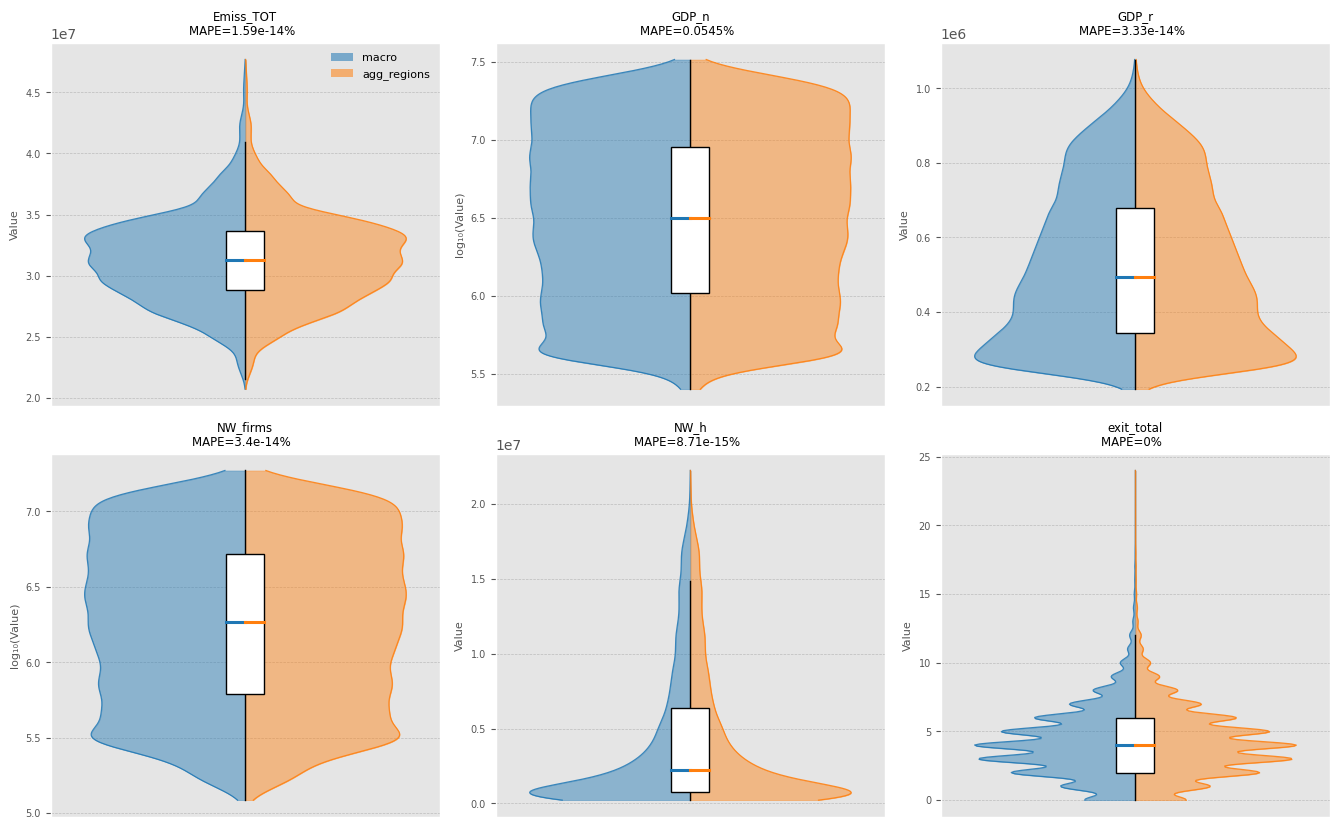

     variable  n_obs     mean_bias           mae          rmse  \
0   Emiss_TOT  30000 -1.332412e-10  4.973883e-09  6.735293e-09   
1       GDP_n  30000 -3.277742e+03  3.277743e+03  5.714189e+03   
2       GDP_r  30000  1.294150e-12  1.716214e-10  2.333883e-10   
3    NW_firms  30000  5.207160e-11  1.179003e-09  2.214268e-09   
4        NW_h  30000  5.152348e-11  3.316673e-10  7.662455e-10   
5  exit_total  30000  0.000000e+00  0.000000e+00  0.000000e+00   

   mean_abs_pct_err  max_abs_pct_err  corr  welch_t_pvalue  cohens_d  \
0      1.591192e-14     2.135398e-13   1.0        1.000000 -0.019786   
1      5.447439e-02     4.355830e-01   1.0        0.952131 -0.700265   
2      3.329784e-14     4.396766e-13   1.0        1.000000  0.005545   
3      3.401966e-14     1.804872e-13   1.0        1.000000  0.023523   
4      8.705806e-15     8.529954e-14   1.0        1.000000  0.067393   
5      0.000000e+00     0.000000e+00   1.0        1.000000  0.000000   

   ks_pvalue  close_ratio  passe

In [129]:
check_regional_consistency(
    scenario_results['large_more_exposed_3'],
    group_keys=("scenario", "run", "t"),
    macro_label="macro",
    alpha=0.05,
    rel_tol=0.01,
    abs_tol=1e-3,
    cols={'aggregate': ['GDP_r', 
    'exit_total', 'GDP_n',
    'Emiss_TOT', 'NW_firms', 'NW_h']},
    output = OUTPUT / "regional_consistency_LPEF.pdf"
)